# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

c:\Users\ASUS TUF GAMING\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
train = pd.read_csv('Minecraft Biomes, etc dataset.csv')
train.head()

,ID,name,dimensionID,treesOrGrass,generateStructures,minecraftVersion,precipitation
0,1,badlands,1,1,1,1.7.2,NaN
1,2,bamboo_jungle,1,1,1,1.14.0,Rain
2,3,basalt_deltas,2,0,1,1.16.0,NaN
3,4,beach,1,0,1,1.0.0,Rain
4,5,birch_forest,1,1,0,1.7.2,Rain


### Exploratory Data Analysis

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  64 non-null     int64 
 1   name                64 non-null     object
 2   dimensionID         64 non-null     int64 
 3   treesOrGrass        64 non-null     int64 
 4   generateStructures  64 non-null     int64 
 5   minecraftVersion    64 non-null     object
 6   precipitation       46 non-null     object
dtypes: int64(4), object(3)
memory usage: 3.6+ KB


In [5]:
d = train.describe()
d

,ID,dimensionID,treesOrGrass,generateStructures
count,64.000000,64.000000,64.000000,64.000000
mean,32.500000,1.265625,0.484375,0.765625
std,18.618987,0.623411,0.503706,0.426956
min,1.000000,1.000000,0.000000,0.000000
25%,16.750000,1.000000,0.000000,1.000000
50%,32.500000,1.000000,0.000000,1.000000
75%,48.250000,1.000000,1.000000,1.000000
max,64.000000,3.000000,1.000000,1.000000


Text(0.5, 1.0, 'Distribusi Precipitation')

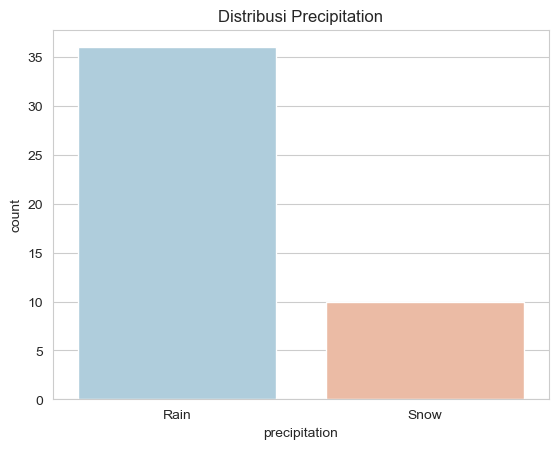

In [6]:
# Cek distribusi target: precipitation
sns.set_style('whitegrid')
sns.countplot(x='precipitation', data=train, palette='RdBu_r')
plt.title('Distribusi Precipitation')

Text(0.5, 1.0, 'Precipitation vs Dimension ID')

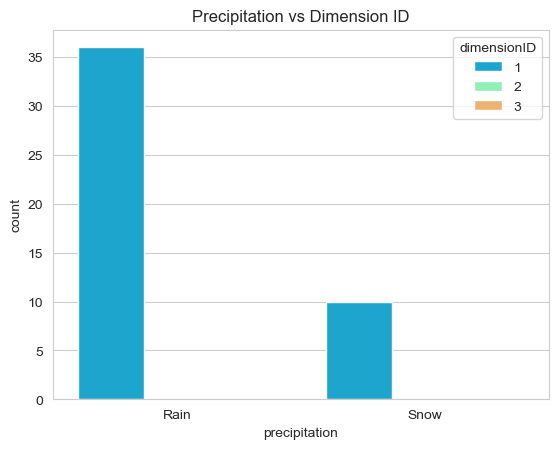

In [7]:
# Precipitation vs dimensionID
sns.set_style('whitegrid')
sns.countplot(x='precipitation', hue='dimensionID', data=train, palette='rainbow')
plt.title('Precipitation vs Dimension ID')

Text(0.5, 1.0, 'Precipitation vs Trees or Grass')

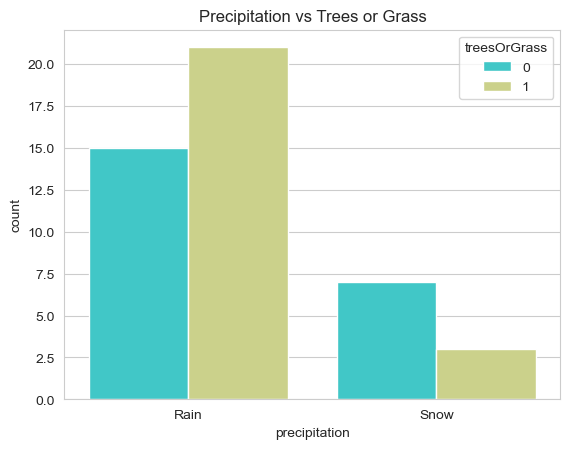

In [8]:
# Precipitation vs treesOrGrass
sns.set_style('whitegrid')
sns.countplot(x='precipitation', hue='treesOrGrass', data=train, palette='rainbow')
plt.title('Precipitation vs Trees or Grass')

Text(0.5, 1.0, 'Precipitation vs Generate Structures')

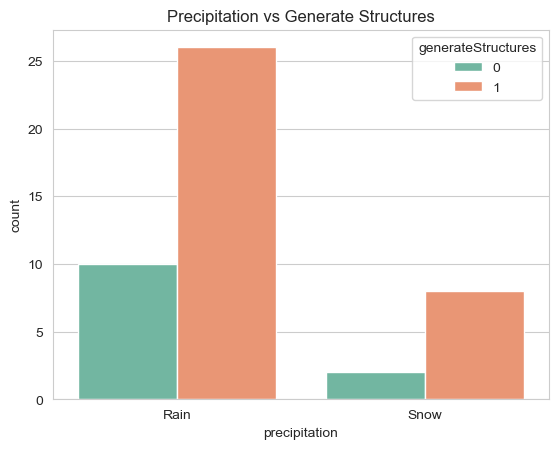

In [9]:
# Precipitation vs generateStructures
sns.set_style('whitegrid')
sns.countplot(x='precipitation', hue='generateStructures', data=train, palette='Set2')
plt.title('Precipitation vs Generate Structures')

Text(0.5, 0, 'Dimension ID')

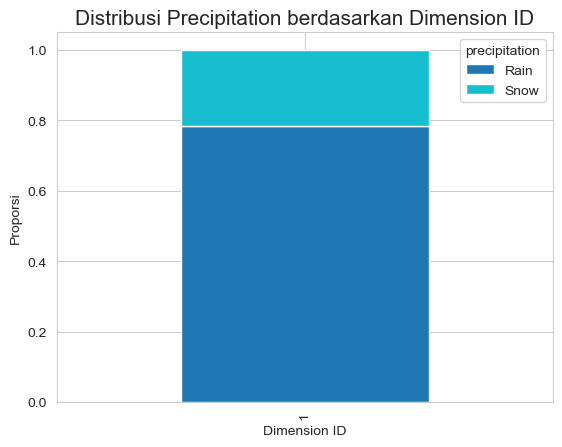

In [10]:
f_dim_precip = train.groupby('dimensionID')['precipitation'].value_counts(normalize=True).unstack().fillna(0)
f_dim_precip.plot.bar(stacked=True, colormap='tab10')
plt.title('Distribusi Precipitation berdasarkan Dimension ID', fontsize=15)
plt.ylabel('Proporsi')
plt.xlabel('Dimension ID')

### Fitur Engineering

In [12]:
# Isi nilai null pada 'precipitation' dengan 'None' (biome tanpa presipitasi)
train['precipitation'] = train['precipitation'].fillna('None')

# Encode minecraftVersion menjadi angka berdasarkan urutan rilis
from sklearn.preprocessing import LabelEncoder

le_version = LabelEncoder()
train['minecraftVersion_enc'] = le_version.fit_transform(train['minecraftVersion'])

# Encode target: precipitation
le_target = LabelEncoder()
train['precipitation_enc'] = le_target.fit_transform(train['precipitation'])

# Tampilkan mapping label
print('Precipitation classes:', le_target.classes_)
train.head()

Precipitation classes: ['None' 'Rain' 'Snow']


,ID,name,dimensionID,treesOrGrass,generateStructures,minecraftVersion,precipitation,minecraftVersion_enc,precipitation_enc
0,1,badlands,1,1,1,1.7.2,None,10,0
1,2,bamboo_jungle,1,1,1,1.14.0,Rain,3,1
2,3,basalt_deltas,2,0,1,1.16.0,None,4,0
3,4,beach,1,0,1,1.0.0,Rain,0,1
4,5,birch_forest,1,1,0,1.7.2,Rain,10,1


In [13]:
# Drop kolom yang tidak dipakai sebagai fitur
train_model = train.drop(['ID', 'name', 'minecraftVersion', 'precipitation'], axis=1)
train_model.head()

,dimensionID,treesOrGrass,generateStructures,minecraftVersion_enc,precipitation_enc
0,1,1,1,10,0
1,1,1,1,3,1
2,2,0,1,4,0
3,1,0,1,0,1
4,1,1,0,10,1


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

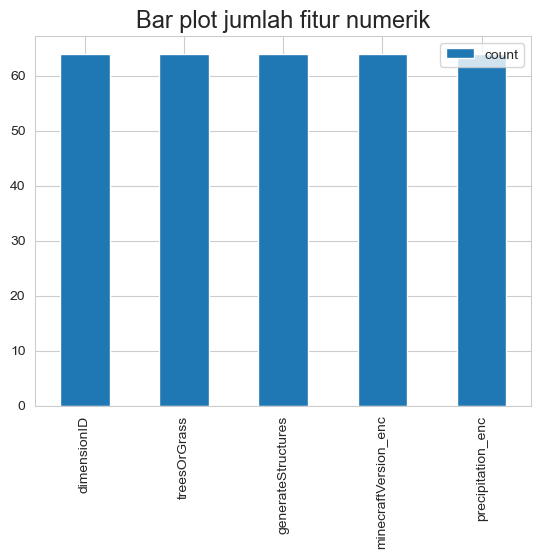

In [14]:
d = train_model.describe()
dT = d.T
dT.plot.bar(y='count')
plt.title('Bar plot jumlah fitur numerik', fontsize=17)

### Training

In [15]:
from sklearn.model_selection import train_test_split

X = train_model.drop('precipitation_enc', axis=1)
y = train_model['precipitation_enc']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (44, 4)
Test shape: (20, 4)


# **KNN**

In [16]:
from sklearn.neighbors import KNeighborsClassifier

clf1 = KNeighborsClassifier()
clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
y_pred = clf1.predict(X_test)

### Evaluation

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

Akurasi Model KNN: 0.70
Confusion Matrix:
[[4 2 0]
 [2 9 1]
 [0 1 1]]
Classification Report:
              precision    recall  f1-score   support

        None       0.67      0.67      0.67         6
        Rain       0.75      0.75      0.75        12
        Snow       0.50      0.50      0.50         2

    accuracy                           0.70        20
   macro avg       0.64      0.64      0.64        20
weighted avg       0.70      0.70      0.70        20



### Jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [19]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, y_pred1)
print(f'Akurasi Model KNN: {accuracy:.2f}')

print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred1))

print('Classification Report:')
print(classification_report(y_test, y_pred1, target_names=le_target.classes_))

Akurasi Model KNN: 0.50
Confusion Matrix:
[[5 1 0]
 [6 5 1]
 [0 2 0]]
Classification Report:
              precision    recall  f1-score   support

        None       0.45      0.83      0.59         6
        Rain       0.62      0.42      0.50        12
        Snow       0.00      0.00      0.00         2

    accuracy                           0.50        20
   macro avg       0.36      0.42      0.36        20
weighted avg       0.51      0.50      0.48        20



### Jika ingin mencoba semua parameter

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print('\n=== Hasil Evaluasi Training (Cross-Validation) ===')
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.538889   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.516667   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.475000   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.475000   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.494444   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.472222   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.494444   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.450000   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.494444   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.450000   
8   {'metric': 'manhattan', 'n_neighbors

In [22]:
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel('hasil_gridsearch_knn_minecraft.xlsx', index=False)
print("Hasil telah disimpan ke 'hasil_gridsearch_knn_minecraft.xlsx'")

Hasil telah disimpan ke 'hasil_gridsearch_knn_minecraft.xlsx'


In [23]:
best_model = grid_search.best_estimator_
print('\n=== Parameter Terbaik ===')
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


In [25]:
y_pred = best_model.predict(X_test)
print('\n=== Evaluasi di Test Set ===')
print(f'Akurasi:  {accuracy_score(y_test, y_pred):.2f}')
print(f'Presisi:  {precision_score(y_test, y_pred, average="macro", zero_division=0):.2f}')
print(f'Recall:   {recall_score(y_test, y_pred, average="macro"):.2f}')
print(f'F1-Score: {f1_score(y_test, y_pred, average="macro"):.2f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le_target.classes_))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.60
Presisi:  0.43
Recall:   0.50
F1-Score: 0.44

Classification Report:
              precision    recall  f1-score   support

        None       0.55      1.00      0.71         6
        Rain       0.75      0.50      0.60        12
        Snow       0.00      0.00      0.00         2

    accuracy                           0.60        20
   macro avg       0.43      0.50      0.44        20
weighted avg       0.61      0.60      0.57        20

Confusion Matrix:
[[6 0 0]
 [5 6 1]
 [0 2 0]]


In [26]:
# Contoh prediksi biome baru
# Fitur: dimensionID, treesOrGrass, generateStructures, minecraftVersion_enc
# Contoh: biome di dimensi overworld (1), ada pohon (1), generate structures (1), versi 1.18.0

new_biome = np.array([[1, 1, 1, le_version.transform(['1.18.0'])[0]]])
prediction = best_model.predict(new_biome)
print('Prediksi Precipitation:', le_target.inverse_transform(prediction)[0])

Prediksi Precipitation: Rain


c:\Users\ASUS TUF GAMING\anaconda3\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
